In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv('./dataset/penguins_size.csv')
df[:5]

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [3]:
numerik_df = df[df.describe().columns]
kategori_df = df.drop(columns=numerik_df)

display(numerik_df)
display(kategori_df)

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
3,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0
...,...,...,...,...
339,NaN,NaN,NaN,NaN
340,46.8,14.3,215.0,4850.0
341,50.4,15.7,222.0,5750.0
342,45.2,14.8,212.0,5200.0


,species,island,sex
0,Adelie,Torgersen,MALE
1,Adelie,Torgersen,FEMALE
2,Adelie,Torgersen,FEMALE
3,Adelie,Torgersen,NaN
4,Adelie,Torgersen,FEMALE
...,...,...,...
339,Gentoo,Biscoe,NaN
340,Gentoo,Biscoe,FEMALE
341,Gentoo,Biscoe,MALE
342,Gentoo,Biscoe,FEMALE


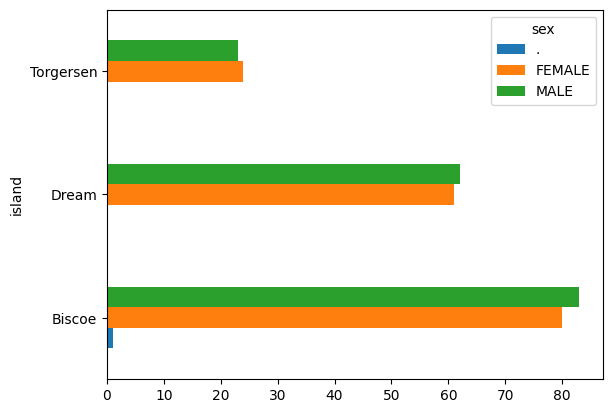

In [4]:
df.pivot_table(values='body_mass_g', columns=['island'], index='sex', aggfunc='count').T.plot(kind='barh')
plt.show()

island  Biscoe         Dream           Torgersen
species Adelie Gentoo Adelie Chinstrap    Adelie
sex                                             
.          NaN    1.0    NaN       NaN       NaN
FEMALE    22.0   58.0   27.0      34.0      24.0
MALE      22.0   61.0   28.0      34.0      23.0

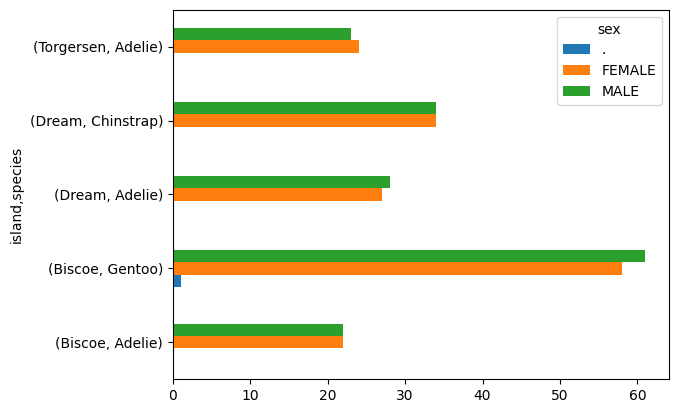

In [5]:
by_islandSpecies = df.pivot_table(values='body_mass_g', columns=['island', 'species'], index='sex', aggfunc='count')

display(by_islandSpecies)
by_islandSpecies.T.plot(kind='barh')
plt.show()

In [6]:
df.pivot_table(values=['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g'], columns=['species'], index='sex', aggfunc='mean')

body_mass_g                           culmen_depth_mm             \
species       Adelie    Chinstrap       Gentoo          Adelie  Chinstrap   
sex                                                                         
.                NaN          NaN  4875.000000             NaN        NaN   
FEMALE   3368.835616  3527.205882  4679.741379       17.621918  17.588235   
MALE     4043.493151  3938.970588  5484.836066       19.072603  19.252941   

                   culmen_length_mm                       flipper_length_mm  \
species     Gentoo           Adelie  Chinstrap     Gentoo            Adelie   
sex                                                                           
.        15.700000              NaN        NaN  44.500000               NaN   
FEMALE   14.237931        37.257534  46.573529  45.563793        187.794521   
MALE     15.718033        40.390411  51.094118  49.473770        192.410959   

                                 
species   Chinstrap      Gentoo  
sex                              
.               NaN  217.000000  
FEMALE   191.735294  212.706897  
MALE     199.911765  221.540984

Dapat disimpulkan bahwa untuk spesies:

1. Adelie:
*    betina memiliki paruh yang tidak lebar dibandingkan jantan rata-rata hanya **17.62 mm** sedangkan jantan **19.07 mm**.
*    betina memiliki panjang paruh relatif pendek dibandinkan jantan dengan rata-rata hanya **37.25 mm** sedangkan jantan **40.4 mm**.
*    betina memiliki kaki yang lebih pendek dibandingkan jantan dengan rata-rata hanya **187.8 mm** sedangkan jantan **192.41 mm**.
*    betina memiliki massa badan lebih kecil dibandingkan jantan dengan rata-rata hanya **3368.8 g** sedangkan jantan **4043.5 g**.

2. Chinstrap
*   betina memiliki paruh yang tidak lebar dibandingkan jantan rata-rata hanya **17.58 mm** sedangkan jantan **19.25 mm**.
*   betina memiliki panjang paruh relatif pendek dibandinkan jantan dengan rata-rata hanya **46.57 mm** sedangkan jantan **51.09 mm**.
*   betina memiliki kaki yang lebih pendek dibandingkan jantan dengan rata-rata hanya **191.73 mm** sedangkan jantan **199.91 mm**.
*   betina memiliki massa badan lebih kecil dibandingkan jantan dengan rata-rata hanya **3527.20 g** sedangkan jantan **3938.97 g**.

3. Gentoo
*   betina memiliki paruh yang tidak lebar dibandingkan jantan rata-rata hanya **14.23 mm** sedangkan jantan **15.71 mm**.
*   betina memiliki panjang paruh relatif pendek dibandinkan jantan dengan rata-rata hanya **45.56 mm** sedangkan jantan **49.47 mm**.
*   betina memiliki kaki yang lebih pendek dibandingkan jantan dengan rata-rata hanya **212.70 mm** sedangkan jantan **221.54 mm**.
*   betina memiliki massa badan lebih kecil dibandingkan jantan dengan rata-rata hanya **4679.741 g** sedangkan jantan **5484.83 g**.

dari keterangan diatas bahwa untuk species :
> * **Gentoo** relatih memiliki **lebar paruh** yang kecil dibandingkan dengan species lain dengan nilai **14.23 mm** sedangkan jantan **15.71 mm**.
> * sedangkan kedua species yang lain memiliki kemiripan nilai

> * **Chinstrap** relatih memiliki **panjang paruh** yang lebih besar dibandingkan dengan species lain dengan nilai **46.57 mm** sedangkan jantan **51.09 mm**.
> * **Adelie** relatih memiliki **panjang paruh** yang lebih kecil dibandingkan dengan species lain dengan nilai **37.25 mm** sedangkan jantan **40.4 mm**.

> * **Gentoo** relatih memiliki **kaki** yang lebih besar dibandingkan dengan species lain dengan nilai **212.70 mm** sedangkan jantan **221.54 mm**.
> * **Adelie** relatih memiliki **kaki** yang lebih kecil dibandingkan dengan species lain dengan nilai **187.8 mm** sedangkan jantan **192.41 mm**.

In [7]:
df[:5]

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [8]:
from itertools import combinations_with_replacement 
comb = combinations_with_replacement(['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g'], 2) 

for i in list(comb): 
    print(i) 

('culmen_length_mm', 'culmen_length_mm')
('culmen_length_mm', 'culmen_depth_mm')
('culmen_length_mm', 'flipper_length_mm')
('culmen_length_mm', 'body_mass_g')
('culmen_depth_mm', 'culmen_depth_mm')
('culmen_depth_mm', 'flipper_length_mm')
('culmen_depth_mm', 'body_mass_g')
('flipper_length_mm', 'flipper_length_mm')
('flipper_length_mm', 'body_mass_g')
('body_mass_g', 'body_mass_g')


In [60]:
def plot_features(df, target_cols, y, cols=2, rows=5):
    plt.figure(figsize=(16, 25))
    comb = combinations_with_replacement(target_cols, 2) 
    for idx, col in enumerate(list(comb)):
        plt.subplot(rows, cols, idx+1)
        sns.scatterplot(data=df, x=col[0], y=col[1], hue=y)

    plt.tight_layout()
    plt.show()

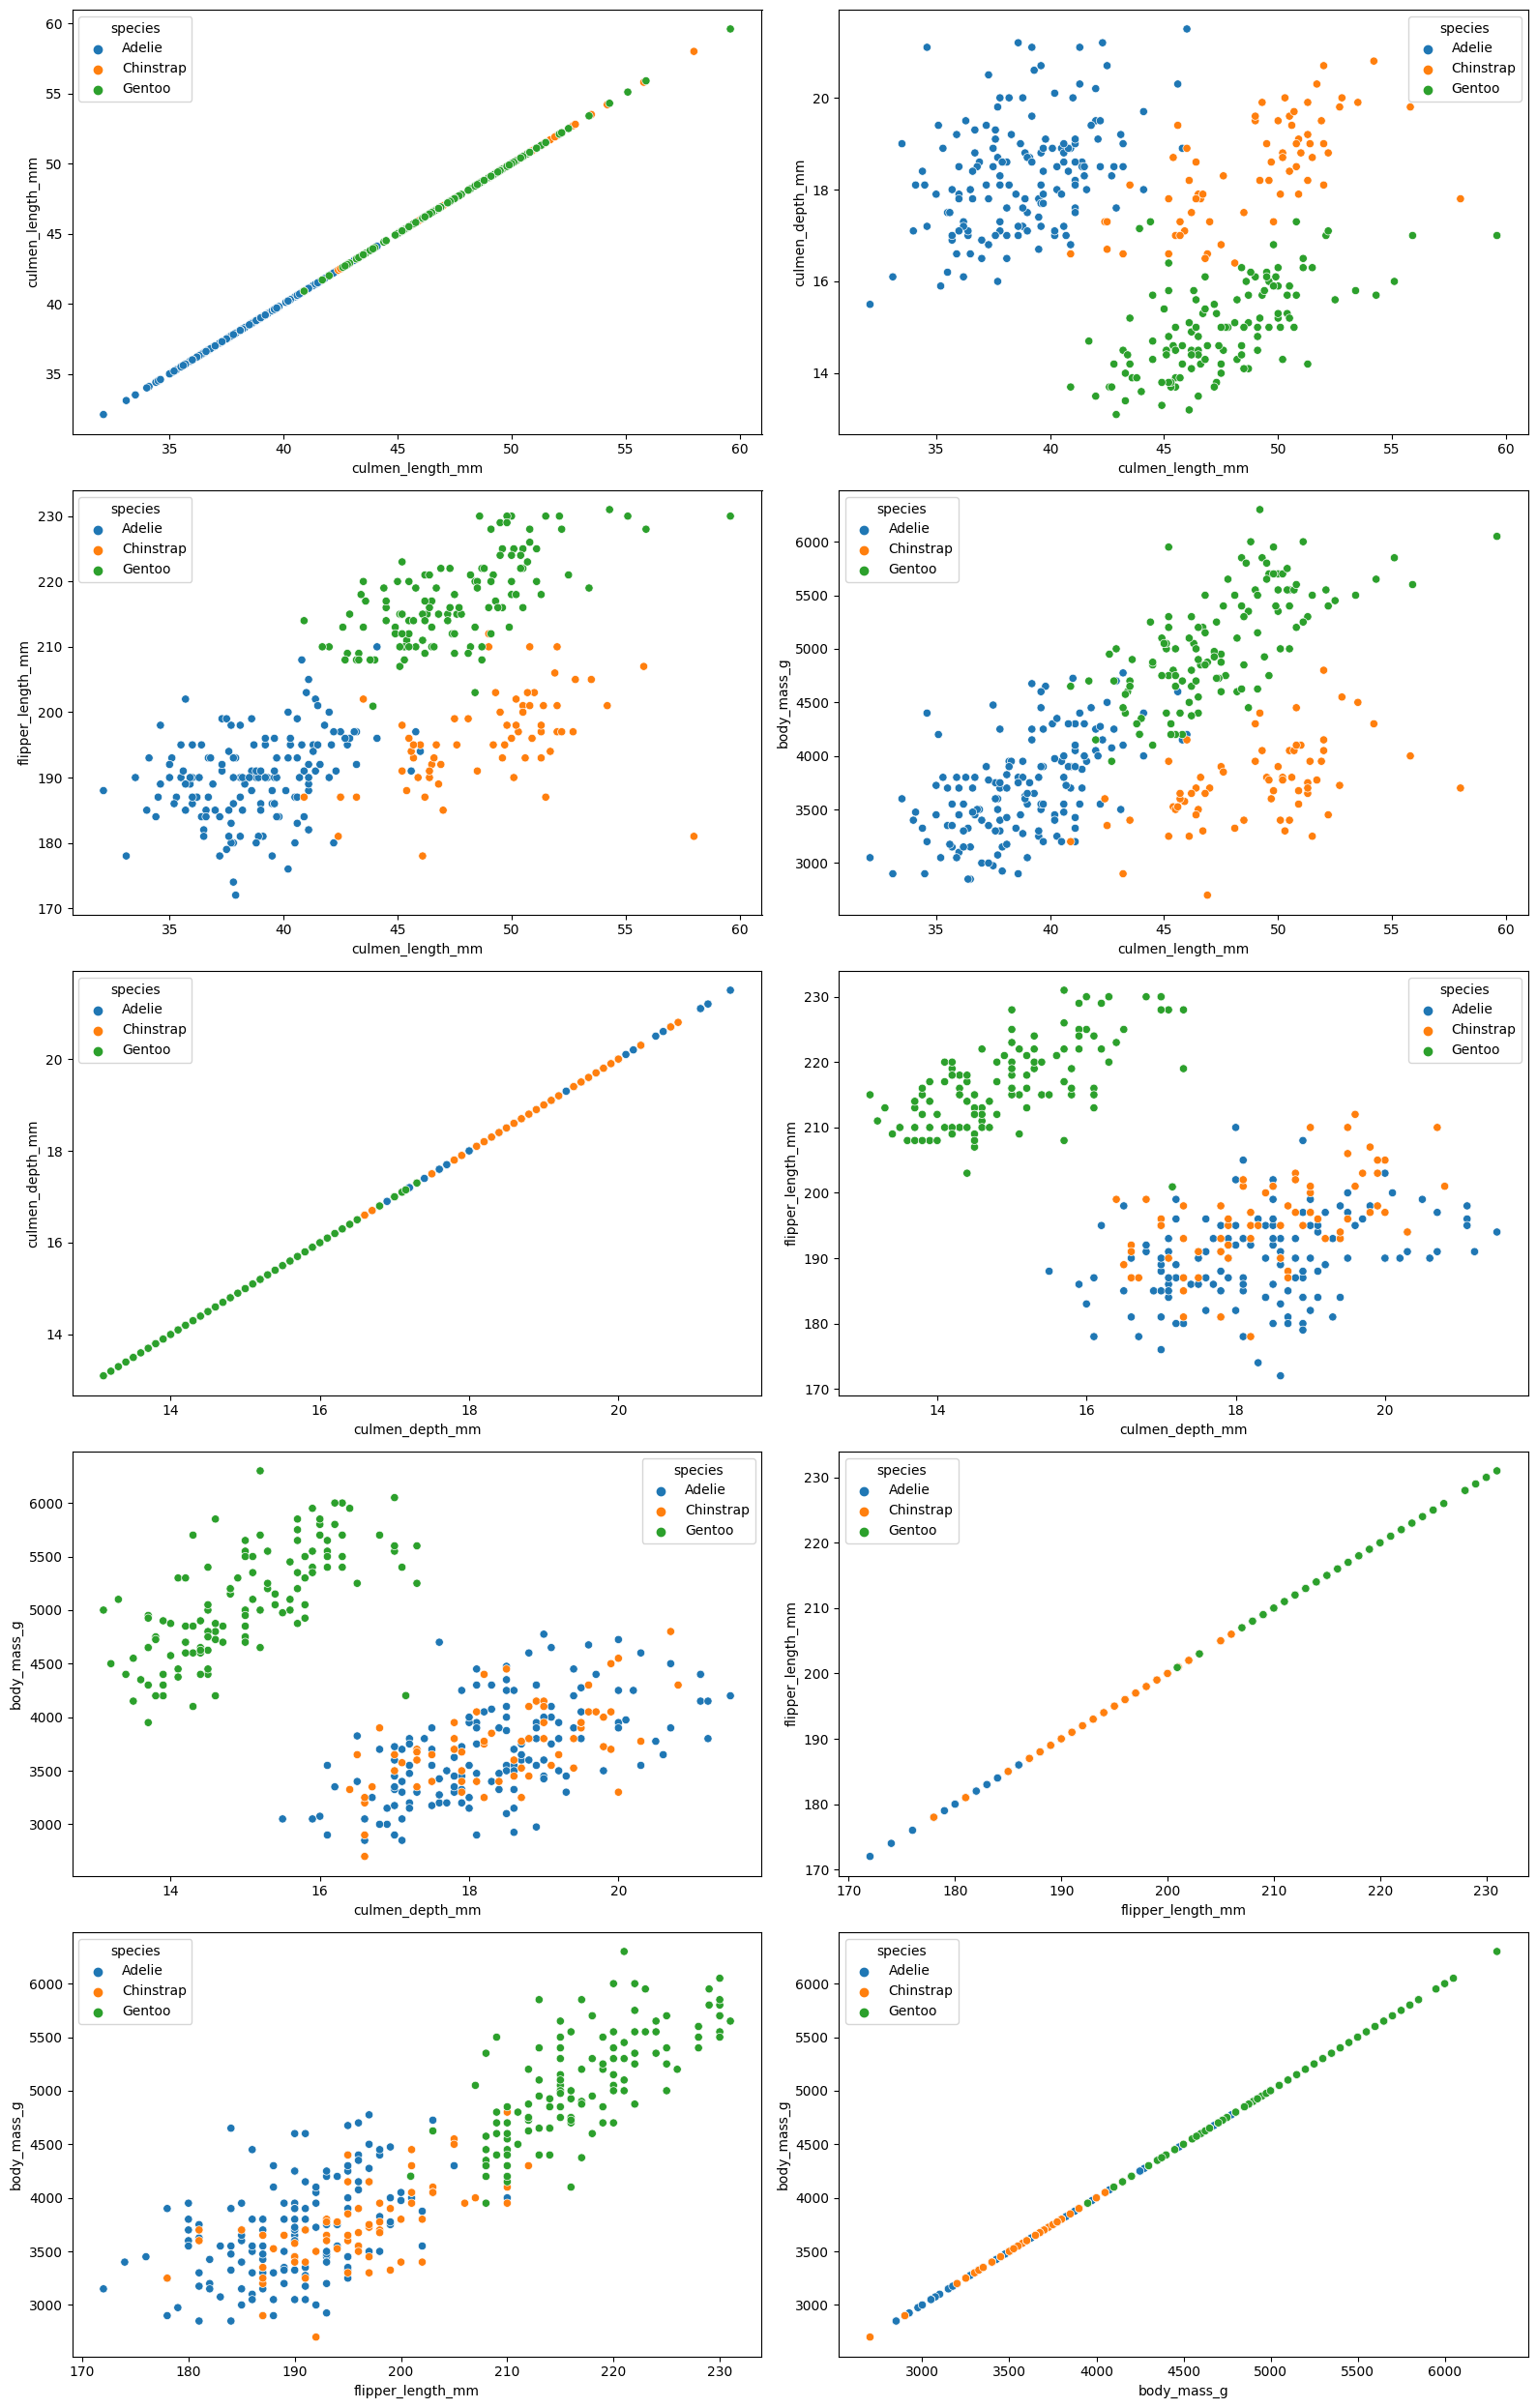

In [61]:
plot_features(df, ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g'], 'species')

In [11]:
def table_diagnose(df):
    new_df = df.copy(deep=True)
    _1 = pd.concat([new_df.isnull().sum(), new_df.nunique(), new_df.dtypes], axis=1, keys=['n null', 'n unique', 'types']).reset_index()

    _2 = new_df.nunique().reset_index()
    _3 = _2.loc[_2[0] < 5, 'index'].apply(lambda x: new_df[x].unique())

    result = pd.merge(_1, _3, left_index=True, right_index=True, how='outer')
    result.rename(columns={'index_x': 'columns', 'index_y':'unique vals'}, inplace=True)
    return result

table_diagnose(df)

,columns,n null,n unique,types,unique vals
0,species,0,3,object,"[Adelie, Chinstrap, Gentoo]"
1,island,0,3,object,"[Torgersen, Biscoe, Dream]"
2,culmen_length_mm,2,164,float64,NaN
3,culmen_depth_mm,2,80,float64,NaN
4,flipper_length_mm,2,55,float64,NaN
5,body_mass_g,2,94,float64,NaN
6,sex,10,3,object,"[MALE, FEMALE, nan, .]"


In [12]:
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [13]:
df[df['sex'].isna()]

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


In [14]:
test_df = df.copy(deep=True)
test_df.loc[[3, 8, 10, 11, 47, 246, 286, 324, 339], 'test'] = 'FEMALE'
test_df.loc[9, 'test'] = 'MALE'
test_df[test_df['sex'].isna()]

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,test
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,FEMALE
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN,FEMALE
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN,MALE
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN,FEMALE
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN,FEMALE
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN,FEMALE
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN,FEMALE
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN,FEMALE
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN,FEMALE
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN,FEMALE


In [15]:
df.loc[[3, 8, 10, 11, 47, 246, 286, 324, 339], 'sex'] = 'FEMALE'
df.loc[9, 'sex'] = 'MALE'

In [16]:
table_diagnose(df)

,columns,n null,n unique,types,unique vals
0,species,0,3,object,"[Adelie, Chinstrap, Gentoo]"
1,island,0,3,object,"[Torgersen, Biscoe, Dream]"
2,culmen_length_mm,2,164,float64,NaN
3,culmen_depth_mm,2,80,float64,NaN
4,flipper_length_mm,2,55,float64,NaN
5,body_mass_g,2,94,float64,NaN
6,sex,0,3,object,"[MALE, FEMALE, .]"


In [17]:
target_cols = numerik_cols_null = numerik_df.isnull().any().index
df[target_cols] = df[target_cols].fillna(df[target_cols].mean())

In [18]:
table_diagnose(df)

,columns,n null,n unique,types,unique vals
0,species,0,3,object,"[Adelie, Chinstrap, Gentoo]"
1,island,0,3,object,"[Torgersen, Biscoe, Dream]"
2,culmen_length_mm,0,165,float64,NaN
3,culmen_depth_mm,0,81,float64,NaN
4,flipper_length_mm,0,56,float64,NaN
5,body_mass_g,0,95,float64,NaN
6,sex,0,3,object,"[MALE, FEMALE, .]"


In [19]:
df[:5]

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.10000,18.70000,181.000000,3750.000000,MALE
1,Adelie,Torgersen,39.50000,17.40000,186.000000,3800.000000,FEMALE
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.000000,FEMALE
3,Adelie,Torgersen,43.92193,17.15117,200.915205,4201.754386,FEMALE
4,Adelie,Torgersen,36.70000,19.30000,193.000000,3450.000000,FEMALE


In [20]:
df[df['sex'] == '.']

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,.


In [21]:
df['sex'].replace({'.':'FEMALE'}, inplace=True)

In [22]:
table_diagnose(df)

,columns,n null,n unique,types,unique vals
0,species,0,3,object,"[Adelie, Chinstrap, Gentoo]"
1,island,0,3,object,"[Torgersen, Biscoe, Dream]"
2,culmen_length_mm,0,165,float64,NaN
3,culmen_depth_mm,0,81,float64,NaN
4,flipper_length_mm,0,56,float64,NaN
5,body_mass_g,0,95,float64,NaN
6,sex,0,2,object,"[MALE, FEMALE]"


species
Adelie       152
Chinstrap     68
Gentoo       124
dtype: int64

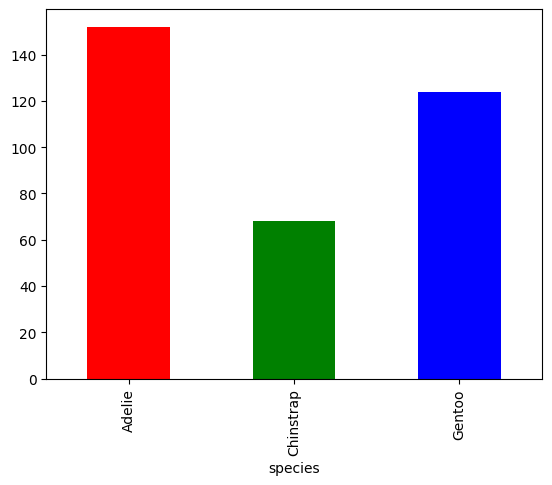

In [23]:
by_species = df.groupby(by='species').size()
display(by_species)
by_species.plot(kind='bar', color=['r', 'g', 'b'])
plt.show()

In [24]:
dummy_df_1 = df.copy(deep='True')

column_transformer = make_column_transformer(
    (OneHotEncoder(), kategori_df.drop(columns='species').columns),
    (MinMaxScaler(), numerik_df.columns)
) # membuat transformer untuk memudahkan dalam proses transformasi data

pipe = Pipeline([
   ("transform", column_transformer),
   ("nan_to_num", FunctionTransformer(np.nan_to_num, validate=False)) # mengambil features name saat di transformasi
])

X_1 = dummy_df_1.drop(columns=['species'])
y_1 = dummy_df_1['species']

X_1_transformed = pipe.fit_transform(dummy_df_1) # transformasi data X

features_name = [i.split('__')[1] for i in pipe.named_steps["transform"].get_feature_names_out()] # menghilangkan nama prepocessor-nya
X_1_df = pd.DataFrame(X_1_transformed, columns=features_name) # menampilkan dalam bentuk DataFrame

le = LabelEncoder()
y_1_transformed = le.fit_transform(y_1)

In [25]:
print(le.classes_)
print(np.unique(y_1_transformed))

['Adelie' 'Chinstrap' 'Gentoo']
[0 1 2]


In [26]:
X_1_df[:5]

,island_Biscoe,island_Dream,island_Torgersen,sex_FEMALE,sex_MALE,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
0,0.0,0.0,1.0,0.0,1.0,0.254545,0.666667,0.152542,0.291667
1,0.0,0.0,1.0,1.0,0.0,0.269091,0.511905,0.237288,0.305556
2,0.0,0.0,1.0,1.0,0.0,0.298182,0.583333,0.389831,0.152778
3,0.0,0.0,1.0,1.0,0.0,0.429888,0.482282,0.490088,0.417154
4,0.0,0.0,1.0,1.0,0.0,0.167273,0.738095,0.355932,0.208333


In [27]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='minority', random_state=42)

X_sm_1, y_sm_1 = smote.fit_resample(X_1_transformed, y_1_transformed)

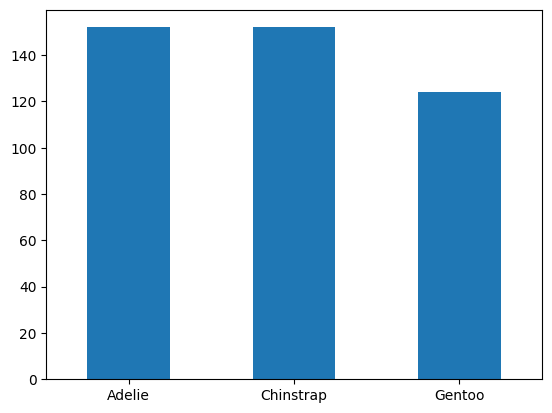

In [28]:
s = pd.Series(y_sm_1)
s.groupby(s).size().plot(kind='bar')
plt.xticks([0, 1, 2], le.classes_, rotation=0)
plt.show()

In [29]:
from sklearn.feature_selection import f_classif
f, p = f_classif(X_sm_1, y_sm_1)

f, p

(array([4.81189229e+02, 4.29870383e+02, 7.12570093e+01, 4.54030472e-03,
        4.54030472e-03, 4.76102456e+02, 4.01312018e+02, 5.81594463e+02,
        4.04294193e+02]),
 array([6.54970079e-110, 8.11620265e-103, 2.05409928e-027, 9.95470035e-001,
        9.95470035e-001, 3.12934221e-109, 1.27718486e-098, 2.19249129e-122,
        4.56000029e-099]))

In [30]:
from sklearn.feature_selection import mutual_info_classif
mi = mutual_info_classif(X_sm_1, y_sm_1)

mi

array([0.45204879, 0.46320227, 0.19344255, 0.        , 0.0094843 ,
       0.59686624, 0.56264603, 0.60220547, 0.54021764])

In [31]:
feature_score = pd.DataFrame(
    {
        'Feature': X_1_df.columns,
        'F': f,
        'MI': mi,
    }
).sort_values(
    'MI', ascending=False
)

feature_score.style.bar(
    subset=['F', 'MI'], color='grey'
)

,Feature,F,MI
7,flipper_length_mm,581.594463,0.602205
5,culmen_length_mm,476.102456,0.596866
6,culmen_depth_mm,401.312018,0.562646
8,body_mass_g,404.294193,0.540218
1,island_Dream,429.870383,0.463202
0,island_Biscoe,481.189229,0.452049
2,island_Torgersen,71.257009,0.193443
4,sex_MALE,0.004540,0.009484
3,sex_FEMALE,0.004540,0.000000


In [73]:
names_column = np.append(X_1_df.columns ,y_1.name)
join_Xy = np.c_[X_sm_1, y_sm_1.reshape(-1, 1)]
new_df = pd.DataFrame(join_Xy, columns=names_column)

display(new_df.shape)
display(new_df.sample(10))

(428, 10)

,island_Biscoe,island_Dream,island_Torgersen,sex_FEMALE,sex_MALE,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,species
296,1.0,0.0,0.0,1.0,0.0,0.560000,0.130952,0.627119,0.527778,2.0
364,0.0,1.0,0.0,1.0,0.0,0.378182,0.474111,0.254237,0.180556,1.0
310,1.0,0.0,0.0,1.0,0.0,0.560000,0.226190,0.779661,0.625000,2.0
35,0.0,1.0,0.0,0.0,1.0,0.258182,0.952381,0.406780,0.402778,0.0
225,1.0,0.0,0.0,1.0,0.0,0.523636,0.047619,0.644068,0.513889,2.0
132,0.0,1.0,0.0,1.0,0.0,0.170909,0.642857,0.355932,0.222222,0.0
289,1.0,0.0,0.0,0.0,1.0,0.676364,0.226190,0.864407,0.791667,2.0
21,1.0,0.0,0.0,0.0,1.0,0.203636,0.666667,0.135593,0.250000,0.0
276,1.0,0.0,0.0,1.0,0.0,0.425455,0.095238,0.610169,0.444444,2.0
383,0.0,1.0,0.0,0.0,1.0,0.728199,0.802505,0.430684,0.281872,1.0


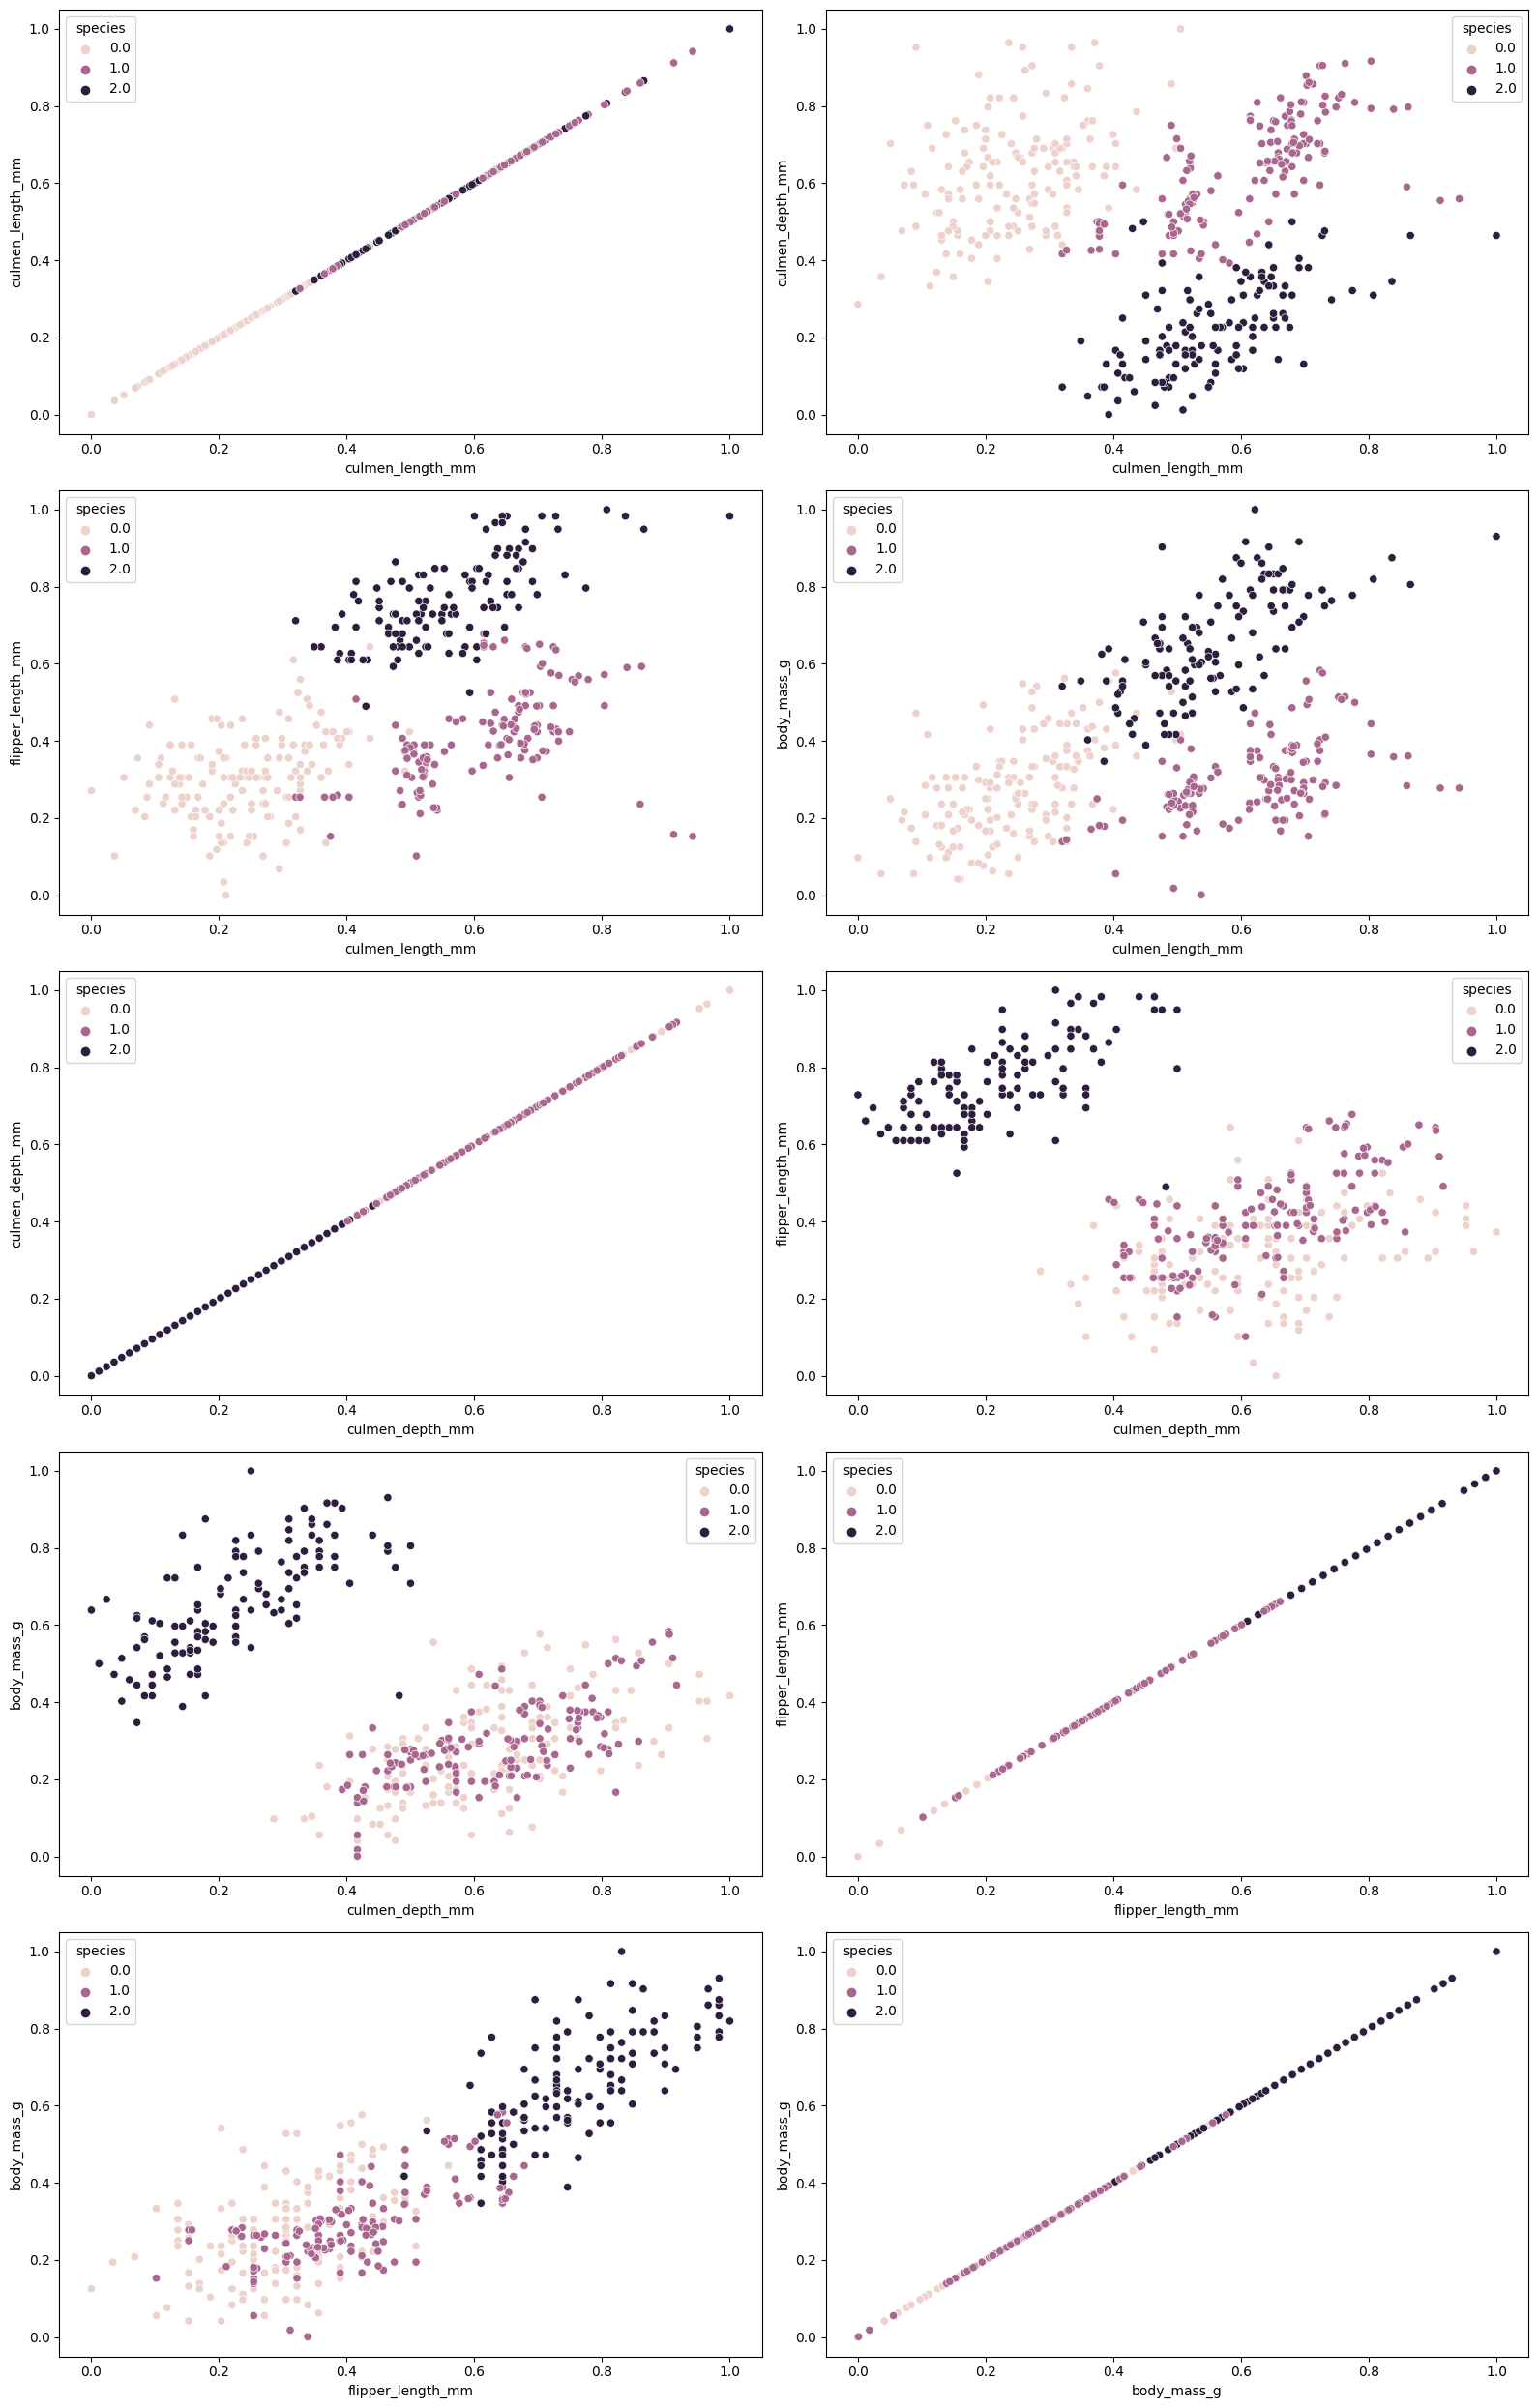

In [68]:
plot_features(new_df, numerik_df.columns, 'species')

In [74]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_validate

In [75]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sm_1,
    y_sm_1,
    test_size=.25,
    random_state=1
)

print(f'X: {X_sm_1.shape}')
print(f'X: {y_sm_1.shape}')
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

X: (428, 9)
X: (428,)
X_train: (321, 9)
y_train: (321,)
X_test: (107, 9)
y_test: (107,)


In [82]:
model_params=[
    {
        'model_name': 'DecisionTreeClassifier',
        'model': DecisionTreeClassifier()
    },
    {
        'model_name': 'RandomForestClassifier',
        'model': RandomForestClassifier()
    },
    {
        'model_name': 'LogisticRegression',
        'model': LogisticRegression()
    },
    {
        'model_name': 'SVM',
        'model': SVC()
    },
    {
        'model_name': 'KNeighborsClassifier',
        'model': KNeighborsClassifier()
    },
    {
        'model_name': 'MultinomialNB',
        'model': MultinomialNB()
    }
]

def tuning_models(X, y, model_params, model_name='model_name', model='model', max_splits=20, get_mean=False):
    rs = ShuffleSplit(n_splits=max_splits, test_size=.2, random_state=0)
    estimated_model = {}
    for idx in range(len(model_params)):
        cv_results = cross_validate(
            model_params[idx]['model'], X, y, cv=rs, scoring='accuracy'
        )
        estimated_model[model_params[idx]['model_name']]= cv_results['test_score']
    df_scoring = pd.DataFrame(estimated_model, index=[f'score {i}' for i in range(max_splits)])
    
    if get_mean:
        for col in df_scoring.columns:
            print(f'{col}: {df_scoring[col].mean()}')
    else:
        return df_scoring

In [85]:
display(tuning_models(X_train, y_train, model_params, 'model_name', 'model', 20))
print(tuning_models(X_train, y_train, model_params, 'model_name', 'model', 20, get_mean=True))

,DecisionTreeClassifier,RandomForestClassifier,LogisticRegression,SVM,KNeighborsClassifier,MultinomialNB
score 0,0.969231,0.984615,1.000000,1.000000,1.000000,0.723077
score 1,1.000000,1.000000,0.984615,0.984615,0.969231,0.661538
score 2,0.984615,0.984615,0.984615,0.969231,0.984615,0.692308
score 3,0.953846,0.969231,0.984615,1.000000,0.984615,0.661538
score 4,1.000000,0.984615,0.984615,0.984615,0.984615,0.753846
score 5,0.984615,1.000000,1.000000,0.984615,1.000000,0.815385
score 6,0.984615,0.984615,1.000000,1.000000,1.000000,0.769231
score 7,0.984615,0.984615,0.984615,1.000000,0.984615,0.676923
score 8,0.969231,1.000000,1.000000,1.000000,1.000000,0.707692
score 9,0.953846,0.953846,1.000000,0.984615,1.000000,0.815385


DecisionTreeClassifier: 0.9776923076923077
RandomForestClassifier: 0.986923076923077
LogisticRegression: 0.99
SVM: 0.9923076923076923
KNeighborsClassifier: 0.9892307692307692
MultinomialNB: 0.726923076923077
None


In [86]:
scores = []

clf = GridSearchCV(
    estimator=SVC(random_state=0),
    param_grid={   
        'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
        'C': [0.5, 1, 10, 100],
        'gamma': ['scale', 'auto', 1, 0.1, 0.01, 0.001]
    },
    cv=20,
    n_jobs=4,
    return_train_score=False
)
clf.fit(X_train, y_train)
scores.append({
    'model': 'SVM',
    'best_score': clf.best_score_,
    'best_params': clf.best_params_
})

In [87]:
cv_df = pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])
cv_df

,model,best_score,best_params
0,SVM,0.996875,"{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}"


In [88]:
from sklearn.metrics import classification_report

model = SVC(C = 100, gamma= 0.1, kernel= 'sigmoid', random_state=0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00        38
           2       1.00      1.00      1.00        41

    accuracy                           1.00       107
   macro avg       1.00      1.00      1.00       107
weighted avg       1.00      1.00      1.00       107



In [90]:
series_pred = pd.Series(le.inverse_transform(y_pred))
series_pred.sample(10)

2     Chinstrap
41    Chinstrap
66    Chinstrap
39       Gentoo
1     Chinstrap
42    Chinstrap
53       Gentoo
82       Gentoo
27       Gentoo
0        Gentoo
dtype: object

In [91]:
series_test = pd.Series(le.inverse_transform(y_test))
series_test.sample(10)

75        Gentoo
82        Gentoo
46        Gentoo
99        Gentoo
56        Gentoo
42     Chinstrap
79     Chinstrap
106    Chinstrap
10        Gentoo
95     Chinstrap
dtype: object

In [120]:
test_pred_df = pd.concat([series_test, series_pred], axis='columns', keys=['test', 'predicted'])
test_pred_df.sample(10)

,test,predicted
101,Adelie,Adelie
42,Chinstrap,Chinstrap
90,Adelie,Adelie
44,Gentoo,Gentoo
59,Chinstrap,Chinstrap
33,Adelie,Adelie
7,Adelie,Adelie
69,Gentoo,Gentoo
55,Chinstrap,Chinstrap
18,Adelie,Adelie


In [227]:
def plot_confusion_matrix(
    matrix,
    class_labels=False,
    figsize=(16, 8), 
    y_ticks_rot=0, 
    x_ticks_rot=0, 
    fs_title=20, 
    fs_label=14, 
    pallete=plt.cm.magma
):
    norm = matrix.sum(axis=1, keepdims=True)

    percentages = ((matrix / norm) * 100).ravel()
    matrices = matrix.ravel()

    cm = np.array([f'{val}\n{percentage:.2f}%' for percentage, val in zip(percentages, matrices)]).reshape(matrix.shape)

    plt.figure(figsize=figsize)

    if class_labels:
        values_labels = [val for val in class_labels.values()]
    else:
        values_labels = "auto"

    sns.heatmap(
        matrix, 
        annot=cm, 
        cmap=pallete, 
        fmt='s', 
        xticklabels=values_labels, 
        yticklabels=values_labels
    )
    plt.xticks(rotation=x_ticks_rot)
    plt.yticks(rotation=y_ticks_rot)
    plt.ylabel('True Label', fontsize=fs_label)
    plt.xlabel('Predicted Label', fontsize=fs_label)
    plt.title('confusion matrix', fontsize=fs_title)
    plt.show()

In [228]:
test_pred_df.unstack().reset_index().pivot_table(index='level_0', columns=0, aggfunc='count')

level_1                 
0          Adelie Chinstrap Gentoo
level_0                           
predicted      28        38     41
test           28        38     41

In [230]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = np.round(model.predict(X_test).ravel())
matrix = confusion_matrix(y_test, y_pred)
matrix

array([[28,  0,  0],
       [ 0, 38,  0],
       [ 0,  0, 41]])

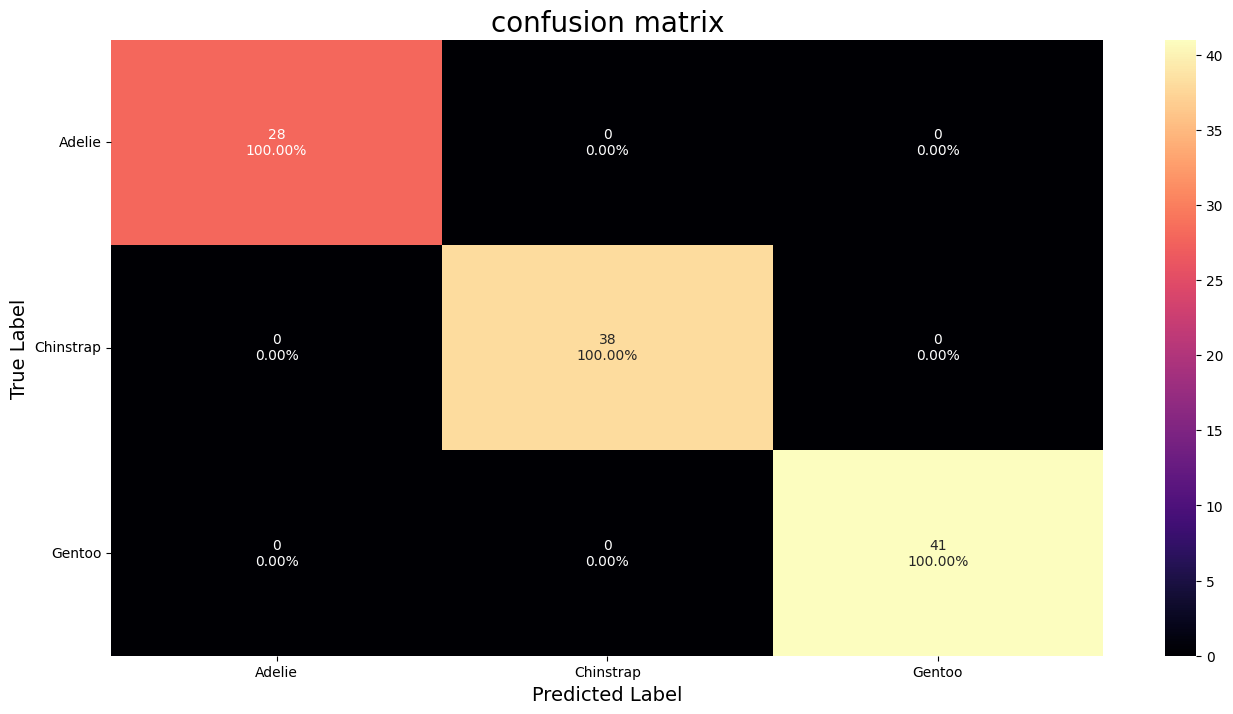

In [231]:
labels = {i:val for i, val in enumerate(le.classes_)}
plot_confusion_matrix(matrix, pallete=plt.cm.magma, class_labels=labels)